(201,)
SASA


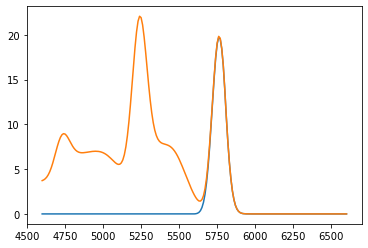

In [ ]:
import importlib
import pymc as pm
import pytensor
import pytensor.tensor as pt
from pathlib import Path
import numpy as np 
from src.scripts.get_matrix_and_specs import get_respmatrix, get_meas_spec

def pytensor_interp(x_new, x_old, y_old):
    return pt.extra_ops.interp(x_new, x_old, y_old)


class binding:
    def __init__(self, 
                 project: str,
                 runnr: int,  
                 savename: str, 
                 bin_width: int = 10, 
                 max_energy = 10000,
                 branchings = True, 
                 br12p2 = False,
                 O_cont = False,
                 ng_cont = False, 
                 bg_bins = 10):
        
        self.project = project
        self.PP = importlib.import_module(f'src.projects.{self.project}.paths').ProjectPaths_Binding()
        self.deconv_params = importlib.import_module(f'src.projects.{self.project}.deconv_params').deconv_params
        self.setup = importlib.import_module(f'src.projects.{self.project}.setup').setup



        
        self.O_cont_bool = O_cont
        self.ng_cont_bool = ng_cont
        self.branch_bool = branchings
        self.br1_2p2_bool = br12p2
        self.bg_bins = bg_bins


        try: 
            self.runnr = int(runnr)
        except:
            self.runnr = str(runnr)
        self.savename = savename
        self.ebeam = self.deconv_params[runnr]['beam']
        self.bin_width = bin_width
        self.bin_centers = np.arange(bin_width, max_energy + bin_width, bin_width)
        self.low = self.deconv_params[runnr]['low']
        self.high = self.deconv_params[runnr]['high']
        self.mask_energy = (self.bin_centers >= self.low) & (self.bin_centers <= self.high) 
        self.td_cut_low = self.deconv_params[runnr]['cut_dets_low']
        self.td_cut_high = self.deconv_params[runnr]['cut_dets_high']
        self.dets = np.array(self.setup['detectors'])
        self.mask_germanium = np.where((np.array(self.setup['types']) == 'Clover') | 
                                       (np.array(self.setup['types']) == 'HPGe'))[0]
        self.mask_scinti = np.where((np.array(self.setup['types']) == 'LaBr') |
                                    (np.array(self.setup['types']) == 'CeBr'))[0]



        def get_cached_data(name: str, low: int, high: int, bin_width: int, compute_func: callable):
            '''
            Check if a cache file exists for given response matrices. If not, a cache file 
            is created, such that initializing binding for a given bin width and lower and upper 
            energy bound is faster.
            '''
            cache_dir = Path(f"{self.PP.SRC_DIR}/../gen/{self.project}/cache_files")
            cache_dir.mkdir(parents= True, exist_ok=True)
            
            file_path = cache_dir / f"{name}_{low}_{high}_bw{bin_width}.npy"
            
            if file_path.exists():
                return np.load(file_path)
            
            print(f"Calculate {name} initial (Cache: {low}-{high} keV, BW: {bin_width})...")
            data = compute_func()
            np.save(file_path, data)
            return data

        def compute_iso_rema() -> np.ndarray:
            '''
            Load isotropic response matrix. The shape of the output is (n_detectors, n_bins, n_bins). 
            You can change the amount of detectors in the setup.py file.  
            '''
            rema_iso = []
            for det in self.setup['detectors']:
                print(f'Get isotropic response matrix of detector {det}...')
                rema_iso.append(
                    get_respmatrix(self.project, '1.5m_0.5m', det, self.bin_width)[np.ix_(self.mask_energy, self.mask_energy)]
                )

            rema_iso = np.array(rema_iso)
            return rema_iso

        
        def compute_16O_rema() -> np.ndarray:
            '''
            Load isotropic response matrix. The shape of the output is (n_detectors, n_bins, n_bins). 
            You can change the amount of detectors in the setup.py file.  
            '''
            rema_16O = []
            for det in self.setup['detectors']:
                print(f'Get response matrix of a 0^+ --> 2^+ --> 0^+ cascade for detector {det}...')
                rema_16O.append(
                    get_respmatrix(self.project, '2p_0p', det, self.bin_width)[np.ix_(self.mask_energy, self.mask_energy)]
                )

            rema_16O = np.array(rema_16O)
            return rema_16O

        def compute_dip_rema() -> np.ndarray:
            '''
            Load response matrices for the decays of dipole excited states to 2^+ or 0^+ states. 
            The shape of the output is (n_detectors, n_dipole_parity, n_states, n_bins, n_bins). 
            n_dipole_parity denotes the two parity options of the spin-1 state, + and -. 
            n_states denotes the number of states that the decay occurs into. The minimum number 
            is n_states = 1 for decays to the ground state. Allowing for decays to excited states
            in the setup.py file increases this number. 
            You can change the amount of detectors in the setup.py file.  
            '''

            rema_dip = [] 
            for det in self.setup['detectors']:
                rema_dip_parities = []
                for parity in ['p', 'm']:
                    rema_dip_spins = []
                    for spin in self.setup['j_states']:
                        sign = '+' if parity == 'p' else '-'
                        print(f'Get response matrix of a 0^+ --> 1^{sign} --> {spin}^+ cascade for detector {det}...')
                        rema_dip_spins.append(
                            get_respmatrix(self.project, f'1{parity}_{spin}p', det, self.bin_width)[np.ix_(self.mask_energy, self.mask_energy)]
                        )
                    rema_dip_parities.append(rema_dip_spins)
                        
                rema_dip.append(rema_dip_parities)
            
            rema_dip = np.array(rema_dip)
            return rema_dip
        

        self.spec_meas_all_dets = pytensor.shared(np.array([
            get_meas_spec('Example', 
                          self.runnr, 
                          det, 
                          self.deconv_params[runnr]['cal'][idx_det], 
                          bin_width, 
                          max_bin = 10000)[self.mask_energy]
            for idx_det, det in enumerate(self.setup['detectors'])
        ]))

        


        self.rema_iso = pytensor.shared(get_cached_data("rema_iso", self.low, self.high, bin_width, lambda: compute_iso_rema()))
        self.rema_16O = pytensor.shared(get_cached_data("rema_16O", self.low, self.high, bin_width, lambda: compute_16O_rema()))
        self.rema_dip = pytensor.shared(get_cached_data("rema_dip", self.low, self.high, bin_width, lambda: compute_dip_rema()))


        self.steps = self.bin_centers[self.mask_energy]
        self.model = self.set_model()

    def set_model(self):
            
        with pm.Model() as model:


            # PRIORS 
            # The ideas behind this deconvolution approach is to describe each bin height as a sum of different cascades (i.e. 1p0p, 1m0p, 1m2p, 1p2p, 1p0pe, 1m0pe). 
            # The priors for the each of the distributions are determined using a top-down deconvolutions. 
            # First, the priors for 1p0p and 1m0p are determined as prior_1m0p = rema_1m0p x spec_L3 and prior_1p0p = rema_1p0p x spec_meas_L1

            # Constant background for detector array 

            bg_const = pm.Deterministic(
                'bg_const', 
                pt.mean(self.spec_meas_all_dets[:, -self.bg_bins:], axis=1),
            )



            if self.ng_cont_bool: # TODO export mean values of n,g distributions to extra file
                # Intoduce ng lines as contaminations in the spectrum. Assume isotropic radiation and a gaussian with a width corresponding to the detector resolution (different for Germanium and Scintillator)
                E_ng = pm.TruncatedNormal('E_ng', [7631, 7645, 7721], lower = [7630, 7644, 7720], upper = [7632, 7646, 7722])
                I_ng = pm.Exponential('I_ng', 1 / 50e3, shape=(E_ng.shape[0],)) 

                ng_width_scinti = pm.Uniform('ng_width_scinti', 5, 50, shape = (len(self.dets[self.mask_scinti]), ))
                ng_width_germanium = pm.Uniform('ng_width_germanium', 5, 15, shape = (len(self.dets[self.mask_germanium]), ))


                sqrt_2pi = np.sqrt(2 * np.pi)
                # Scintillator detectors
                ng_inc_scinti = pm.Deterministic('ng_inc_scinti', 
                    pt.clip(
                        pt.sum(
                            (I_ng[None, :, None] / (sqrt_2pi * ng_width_scinti[:, None, None])) * pt.exp(-0.5 * ((self.bin_centers[self.mask_energy][None, None, :] - E_ng[None, :, None]) / ng_width_scinti[:, None, None]) ** 2),
                            axis=1
                        ), 1e-6, pt.inf
                    )
                )# dimensions (dets, bins)

                # Germanium detectors
                ng_inc_germanium = pm.Deterministic('ng_inc_germanium', 
                    pt.clip(
                        pt.sum(
                            (I_ng[None, :, None] / (sqrt_2pi * ng_width_germanium[:, None, None])) * pt.exp(-0.5 * ((self.bin_centers[self.mask_energy][None, None, :] - E_ng[None, :, None]) / ng_width_germanium[:, None, None]) ** 2),
                            axis=1
                        ), 1e-6, pt.inf
                    )
                )# dimensions (dets, bins)

                # Fold both incident spectra with corresponding detector response matrices
                ng_fold_scinti = pm.Deterministic('ng_fold_scinti', self.rema_iso[self.mask_scinti][:, ::-1, ::-1] @ ng_inc_scinti[:, :, None])[:, :, 0]  # shape (det, bins) x (det, bins, bins) -> (det, ng, bins)
                ng_fold_germanium = pm.Deterministic('ng_fold_germanium', self.rema_iso[self.mask_germanium][:, ::-1, ::-1] @ ng_inc_germanium[:,:, None])[:, :, 0] # shape (det, binss) x (det, bins, bins) -> (det, ng, bins)


            
            if self.O_cont_bool:
                # Intoduce 16O as contaminations in the spectrum. Assume isotropic radiation and a gaussian with a width corresponding to the detector resolution (different for Germanium and Scintillator)
                # E_O_scinti = pm.TruncatedNormal('E_O_scinti', [6910], lower = [6900], upper = [6950])
                # E_O_germanium = pm.TruncatedNormal('E_O_germanium', [6910], lower = [6900], upper = [6930])

                E_O_scinti = pm.TruncatedNormal('E_O_scinti', [5750], lower = [5740], upper = [5760], shape = (1,))
                E_O_germanium = pm.TruncatedNormal('E_O_germanium', [5750], lower = [5740], upper = [5760], shape = (1, ))


                I_O = pm.Exponential('I_O', 1 / 100e3, shape=(1,)) 
                O_width_scinti = pm.Uniform('O_width_scinti', 5, 50, shape = (len(self.dets[self.mask_scinti]), ))
                O_width_germanium = pm.Uniform('O_width_germanium', 5, 15, shape = (len(self.dets[self.mask_scinti]), ))
                sqrt_2pi = np.sqrt(2 * np.pi)

                # Scintillator dets
                O_inc_scinti = pm.Deterministic('O_inc_scinti', 
                    pt.clip(
                        pt.sum(
                            (I_O[None, :, None] / (sqrt_2pi * O_width_scinti[:, None, None])) * pt.exp(-0.5 * ((self.bin_centers[self.mask_energy][None, None, :] - E_O_scinti[None, :, None]) / O_width_scinti[:, None, None]) ** 2),
                            axis=1
                        ), 1e-6, pt.inf
                    )
                )# dets, bin

                # Germanium dets
                O_inc_germanium = pm.Deterministic('O_inc_germanium', 
                    pt.clip(
                    pt.sum(
                        (I_O[None, :, None] / (sqrt_2pi * O_width_germanium[:, None, None])) * pt.exp(-0.5 * ((self.bin_centers[self.mask_energy][None, None, :] - E_O_germanium[None, :, None]) / O_width_germanium[:, None, None]) ** 2),
                        axis=1
                    ), 1e-6, pt.inf
                    )
                )# dets, bins


                # Fold both incident spectra with corresponding detector response matrices
                O_fold_scinti = pm.Deterministic('O_fold_scinti', self.rema_16O[self.mask_scinti][:, ::-1, ::-1] @ O_inc_scinti[:, :, None])[:, :, 0]  # shape (det, bins) x (det, bins, bins) -> (det, ng, bins)
                O_fold_germanium = pm.Deterministic('O_fold_germanium', self.rema_16O[self.mask_germanium][:, ::-1, ::-1] @ O_inc_germanium[:, :, None])[:, :, 0] # shape (det, binss) x (det, bins, bins) -> (det, ng, bins)


            return model






a = binding('Example', 179, 'bins', O_cont=True )


In [ ]:
.eval()), np